# Diabetes risk prediction: one MLP, three implementations

This notebook builds a single binary classifier for whether a BRFSS survey
respondent has diabetes, using the same multi-layer perceptron architecture
implemented three separate times: once by hand with NumPy only, once with
TensorFlow/Keras, and once with PyTorch. The point is not to find the best
possible model. It is to hold the architecture, the data, and the training
setup fixed, and see what actually changes when the same computation is
expressed at a different level of abstraction.

The data here is tabular. Each row is a survey respondent, and each column
is a numeric or categorical answer to a health question. There is no spatial
relationship between neighboring columns the way there is between neighboring
pixels in an image, so a convolutional layer would not have anything to
exploit. A plain feedforward network (an MLP) is the natural fit for this
kind of data, which is why this notebook builds an MLP rather than a CNN:
the architecture is chosen to match the structure of the data, not picked
ahead of time.

Every code cell below is paired with a markdown cell explaining what it does
and why, especially in the from-scratch section, since writing out the
forward pass, the loss, and the backward pass by hand is the part of this
notebook that most directly shows whether the underlying math is actually
understood.

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)
import joblib
import json

# Framework imports, kept separate from the numpy-only imports the scratch
# section restricts itself to below.
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

sns.set_theme(style="whitegrid")

The random seed is fixed once, here, and reused everywhere a random choice
gets made: the train/test split, NumPy's own weight initialization, and both
frameworks' internal random state. This is what makes a rerun reproducible,
and it is also part of what makes the three implementations a fair
comparison. If each implementation shuffled or initialized differently, a
difference in results could just be luck rather than something about the
implementation itself.

In [2]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
import random
random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

## Loading the data

The dataset comes from five years (2016 through 2020) of the BRFSS health
survey, one CSV file per year, all pulled from the same source. Before
concatenating them into one table, it is worth checking whether every year
actually has the same columns. Survey instruments change over time: a
question added in one year might not exist in another, and silently
concatenating mismatched columns would either fill an entire year with
missing values or, worse, misalign columns without anyone noticing. So the
first step loads each year separately and compares column sets before
combining anything.

In [3]:
YEARS = [2016, 2017, 2018, 2019, 2020]
DATA_DIR = "../data"

yearly_frames = {}
for y in YEARS:
    yearly_frames[y] = pd.read_csv(f"{DATA_DIR}/DATASET_{y}.csv")

for y in YEARS:
    print(y, "->", yearly_frames[y].shape[1], "columns")

column_sets = {y: set(df.columns) for y, df in yearly_frames.items()}
common_columns = set.intersection(*column_sets.values())
all_columns = set.union(*column_sets.values())
extra_columns = all_columns - common_columns

print()
print("Columns not shared by all 5 years:", sorted(extra_columns))
for col in sorted(extra_columns):
    years_with_col = sorted(y for y, cols in column_sets.items() if col in cols)
    print(f"  {col}: present in {years_with_col}")

2016 -> 31 columns
2017 -> 33 columns
2018 -> 31 columns
2019 -> 33 columns
2020 -> 31 columns

Columns not shared by all 5 years: ['high_bp_00', 'high_cholesterol_00']
  high_bp_00: present in [2017, 2019]
  high_cholesterol_00: present in [2017, 2019]


Two columns, `high_bp_00` and `high_cholesterol_00`, only show up in 2017 and
2019. Every other column is shared across all five years. Those two columns
get dropped rather than kept with three years of missing values, since a
column that's structurally absent (not just unanswered) for 60% of the years
would need a different missingness-handling story than a real not-a-number
value, and it's simpler and more honest to just not use it this round. The
concatenation below intersects on columns first, so this is explicit rather
than something `pandas.concat` decides for us by silently filling gaps with
NaN.

In [4]:
df = pd.concat(
    [yearly_frames[y][sorted(common_columns)] for y in YEARS],
    ignore_index=True,
)
print(df.shape)

(2181125, 31)


## Data understanding

With everything loaded into one table, the next step is just looking at it:
how many rows, what type each column actually is, and a summary of the
numeric ones. Five years of BRFSS survey data, each year with a few hundred
thousand respondents, should land somewhere in the low millions once
concatenated, and this is the point where that actually gets confirmed
rather than assumed.

In [5]:
print("Shape:", df.shape)
print()
print(df.dtypes)

Shape: (2181125, 31)

age_00                           float64
age_group_00                      object
avg_drinks_p_day_00              float64
bmi_00                           float64
cost_barrier_00                   object
diabetes                          object
drinks_alcohol_00                 object
education_00                     float64
education_level_00                object
employment_status_00              object
exercise_00                       object
gen_health_00                    float64
general_health_00                 object
had_coronary_heart_disease_00     object
had_heart_attack_00               object
had_stroke_00                     object
has_personal_doctor_00            object
height_00                        float64
income_00                        float64
income_level_00                   object
l_checkup_00                     float64
last_checkup_00                   object
marital_status_00                 object
mental_health_days_00            fl

In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age_00,2146012.0,NaN,NaN,NaN,7.659115,3.531048,1.0,5.0,8.0,10.0,13.0
age_group_00,2146012,13,65 to 69,238550,NaN,NaN,NaN,NaN,NaN,NaN,NaN
avg_drinks_p_day_00,1036656.0,NaN,NaN,NaN,2.247037,2.522966,0.0,1.0,2.0,2.0,76.0
bmi_00,2007209.0,NaN,NaN,NaN,28.222466,6.42284,2.81,23.91,27.26,31.32,377.79
cost_barrier_00,2174309,2,False,1954497,NaN,NaN,NaN,NaN,NaN,NaN,NaN
diabetes,2181125,3,Non-diabetic,1841657,NaN,NaN,NaN,NaN,NaN,NaN,NaN
drinks_alcohol_00,2061656,2,True,1059101,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education_00,2172776.0,NaN,NaN,NaN,4.929109,1.03464,1.0,4.0,5.0,6.0,6.0
education_level_00,2172776,6,College 4 years or more (College graduate),815367,NaN,NaN,NaN,NaN,NaN,NaN,NaN
employment_status_00,2155761,8,Employed for wages,887857,NaN,NaN,NaN,NaN,NaN,NaN,NaN


A few of the numeric columns are worth a closer look before anything gets
scaled. BRFSS surveys use specific sentinel codes for "don't know" or
"refused to answer" instead of just leaving a cell blank, and those codes can
be far outside the range of a real answer. `weight_00`'s max of 999 pounds is
one of those: nobody actually weighs 999 pounds, so that's almost certainly
the survey's placeholder for a non-answer, not a real observation. The same
kind of thing can happen with `bmi_00`, where a small number of clearly
implausible values (well above what's physically possible) usually come from
the same kind of coding quirk rather than genuine outliers.

In [7]:
print("weight_00 top values:")
print(df["weight_00"].value_counts().head(10))
print()
print("bmi_00 above 100:", (df["bmi_00"] > 100).sum(), "rows")
print(df.loc[df["bmi_00"] > 100, "bmi_00"].describe())

weight_00 top values:
weight_00
200.0    107186
180.0    100294
150.0     94206
160.0     91137
170.0     82736
190.0     71049
140.0     68604
175.0     58608
165.0     54580
130.0     53282
Name: count, dtype: int64

bmi_00 above 100: 167 rows
count    167.000000
mean     132.681557
std       38.521959
min      100.130000
25%      108.480000
50%      116.930000
75%      145.025000
max      377.790000
Name: bmi_00, dtype: float64


Both confirm the suspicion: `weight_00` has a large spike exactly at 999
(a round, out-of-range sentinel value that wouldn't happen by chance in real
weight data), and every `bmi_00` value above 100 is a similar coding
artifact rather than a real body mass index. These get cleaned to genuine
missing values in the cleaning section below, not left in as if they were
real measurements.

Missing data shows up throughout this dataset for a more mundane reason too:
BRFSS asks some questions conditionally. `avg_drinks_p_day_00` is only asked
of people who said yes to drinking alcohol at all, so it's expected to be
missing for a large fraction of respondents, not a data quality problem.

In [8]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)
pd.DataFrame({"missing": missing, "pct": missing_pct}).query("missing > 0")

,missing,pct
avg_drinks_p_day_00,1144469,52.5
poor_health_days_00,1060238,48.6
income_00,387772,17.8
income_level_00,387772,17.8
bmi_00,173916,8.0
weight_00,153041,7.0
drinks_alcohol_00,119469,5.5
smoked_100_cigarettes_00,90920,4.2
height_00,87302,4.0
exercise_00,57547,2.6


Now for the target itself. `diabetes` has three categories rather than two:
non-diabetic, pre-diabetic, and diabetic. This notebook treats it as a binary
problem, non-diabetic versus everyone else, which means the class balance
that actually matters for training is the binary one, not the three-way
split shown here first for context.

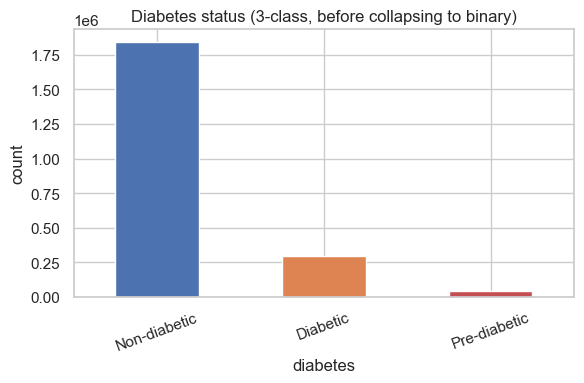

In [9]:
plt.figure(figsize=(6, 4))
df["diabetes"].value_counts().plot(kind="bar", color=["#4C72B0", "#DD8452", "#C44E52"])
plt.title("Diabetes status (3-class, before collapsing to binary)")
plt.ylabel("count")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

Diabetic and pre-diabetic respondents are both a small minority next to the
non-diabetic majority, and merging them into one positive class below does
not change that: the resulting binary target stays meaningfully imbalanced.
Left unaddressed, that kind of imbalance tends to make a model learn to
predict the majority class most of the time, since doing so already gets a
low average loss without learning to separate the two classes at all. The
fix used later, once the target and the train/test split exist, is to give
each row's loss a weight based on how common its class is, so the rare
class counts for as much in total as the common one does.

BMI is one of the more direct clinical predictors of diabetes risk, so it's
worth checking whether that relationship actually shows up in this data
before building any model around it.

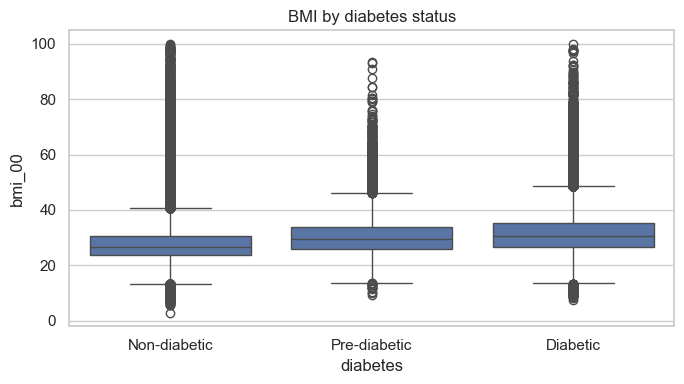

In [10]:
plot_df = df[["bmi_00", "diabetes"]].dropna()
plot_df = plot_df[plot_df["bmi_00"] <= 100]  # drop the sentinel-region values for this plot

plt.figure(figsize=(7, 4))
sns.boxplot(data=plot_df, x="diabetes", y="bmi_00",
            order=["Non-diabetic", "Pre-diabetic", "Diabetic"])
plt.title("BMI by diabetes status")
plt.tight_layout()
plt.show()

The median BMI climbs from non-diabetic to pre-diabetic to diabetic, which
is the direction the clinical literature would predict. It's not a sharp
separation (there's a lot of overlap in the boxes), which matches how BMI is
a risk factor among several, not something that alone determines the
outcome. That overlap is itself useful context for interpreting whatever
accuracy the models below end up with: a feature set where no single column
cleanly separates the classes is a dataset where a model landing well below
perfect accuracy is expected, not a sign of a bug.

General health self-rating (`gen_health_00`, coded 1 for Excellent through 5
for Poor) is another column worth checking, since a respondent's own sense
of their health is often a strong summary signal that a single lab
measurement like BMI can miss.

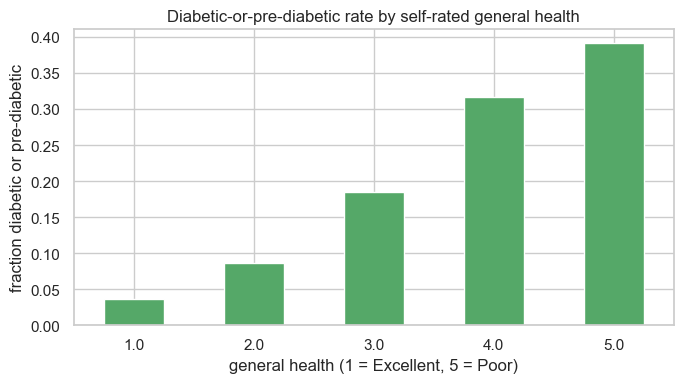

In [11]:
plot_df = df[["gen_health_00", "diabetes"]].dropna()
rate_by_health = (
    plot_df.assign(is_diabetic=lambda d: d["diabetes"] != "Non-diabetic")
    .groupby("gen_health_00")["is_diabetic"]
    .mean()
)

plt.figure(figsize=(7, 4))
rate_by_health.plot(kind="bar", color="#55A868")
plt.title("Diabetic-or-pre-diabetic rate by self-rated general health")
plt.xlabel("general health (1 = Excellent, 5 = Poor)")
plt.ylabel("fraction diabetic or pre-diabetic")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The rate rises steadily from Excellent to Poor, which makes sense: diabetes
is exactly the kind of chronic condition that would push someone's own
sense of their health downward. This is a much stronger, more monotonic
relationship than the BMI one above, which suggests `gen_health_00` is
likely to carry real signal for the models trained below.

Finally, since this dataset spans five separate survey years, it's worth
checking whether the diabetes rate actually moved over that period, or
whether `year` is just noise that happens to have five levels. If diabetes
prevalence were flat across 2016 to 2020, `year` would mostly be adding
dimensionality without adding information.

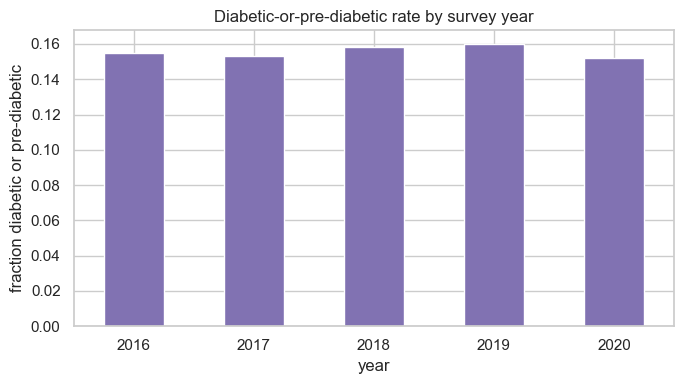

year
2016    0.154961
2017    0.153036
2018    0.158507
2019    0.159679
2020    0.152041
Name: is_diabetic, dtype: float64


In [12]:
plot_df = df[["year", "diabetes"]].dropna()
rate_by_year = (
    plot_df.assign(is_diabetic=lambda d: d["diabetes"] != "Non-diabetic")
    .groupby("year")["is_diabetic"]
    .mean()
)

plt.figure(figsize=(7, 4))
rate_by_year.plot(kind="bar", color="#8172B2")
plt.title("Diabetic-or-pre-diabetic rate by survey year")
plt.ylabel("fraction diabetic or pre-diabetic")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print(rate_by_year)

The rate does drift across years rather than sitting flat, so `year` is kept
as a candidate feature below rather than dropped outright. Whether it
actually helps the model is a separate question from whether it moves at
all, but a flat rate would have been a much stronger reason to drop it.

## Data cleaning

Cleaning happens in a few separate, small steps rather than one big cell, so
each decision is visible and undoable on its own.

In [13]:
# Step 1: collapse the 3-class target to binary. Pre-diabetic and diabetic
# both count as the positive class, matching how the assignment frames this
# as a binary classification problem.
df["target"] = (df["diabetes"] != "Non-diabetic").astype(int)
print(df["target"].value_counts())

target
0    1841657
1     339468
Name: count, dtype: int64


Several of the `_00` columns are string versions of information that
already exists as a clean numeric ordinal column elsewhere in the table:
`age_group_00` is the same information as `age_00`, just as a text range
instead of a number 1 through 13, and the same pattern holds for
`education_level_00`/`education_00`, `income_level_00`/`income_00`,
`general_health_00`/`gen_health_00`, and `last_checkup_00`/`l_checkup_00`.
Keeping both would either double-count the same signal or require re-encoding
the string version from scratch for no benefit, so the string duplicates get
dropped and the numeric ordinal versions are kept.

In [14]:
# Step 2: drop the string columns that duplicate a numeric ordinal column
# already present elsewhere in the table.
duplicate_string_columns = [
    "age_group_00",
    "education_level_00",
    "income_level_00",
    "general_health_00",
    "last_checkup_00",
]
df = df.drop(columns=duplicate_string_columns)
print("Remaining columns:", df.shape[1])

Remaining columns: 27


Now for the sentinel values found earlier: `weight_00` values of exactly 999
and `bmi_00` values above 100 are placeholder codes, not real measurements,
so they get replaced with a genuine missing value and then filled in with
the median of the column. Using the median rather than the mean keeps the
imputed value robust to whatever other outliers are still in the data, and
computing it is deferred until after the train/test split below, so the
imputation value itself is learned only from the training data.

In [15]:
# Step 3: sentinel values to NaN. The actual imputation (median fill) happens
# after the train/test split, so it can be fit on the training data only.
df.loc[df["weight_00"] == 999, "weight_00"] = np.nan
df.loc[df["bmi_00"] > 100, "bmi_00"] = np.nan
print("weight_00 missing now:", df["weight_00"].isna().sum())
print("bmi_00 missing now:", df["bmi_00"].isna().sum())

weight_00 missing now: 153060
bmi_00 missing now: 174083


## Representation

With cleaning done, the remaining columns fall into three groups that each
need a different treatment before they can go into a neural network, since a
network only understands numbers, and it understands them better when
they're on a comparable scale.

The first group is genuinely two-valued: things like whether the respondent
smokes, whether they've had a stroke, or their sex. These arrive as
True/False or Yes/No and map directly onto 0 and 1 with no information lost.

The second group is genuinely multi-category with no natural order: race,
marital status, employment status, and how many personal doctors someone
has. Turning "Married" into the number 3 would imply an ordering between
marital statuses that doesn't exist, so these get one-hot encoded instead,
each category becoming its own 0/1 column.

The third group covers everything numeric: the ordinal survey codes
(general health 1 through 5, education 1 through 6, and so on), the
genuinely continuous measurements (BMI, weight, height), and `year` itself.
A single-digit ordinal code and a three-digit weight in pounds already sit
on very different scales from each other, and `year` would be worse still
if left as a raw calendar value: 2016 through 2020 is several times larger
in magnitude than every other feature on this list. A column that
dominates the input like that can dominate the first layer's weighted sum
before training has any real chance to learn something better than always
predicting the majority class, since the network spends its first updates
just fighting that one oversized input rather than learning the actual
relationship between features and target. The fix here is to put every
numeric, non-binary column into one `StandardScaler` group, `year` included,
rather than trying to reason about which particular columns are "small
enough" to leave unscaled.

In [16]:
binary_yes_no_columns = [
    "sex_00",
    "exercise_00",
    "smoked_100_cigarettes_00",
    "drinks_alcohol_00",
    "had_stroke_00",
    "had_heart_attack_00",
    "had_coronary_heart_disease_00",
    "cost_barrier_00",
]

nominal_columns = [
    "race_00",
    "marital_status_00",
    "employment_status_00",
    "has_personal_doctor_00",
]

numeric_columns = [
    "year",
    "age_00",
    "weight_00",
    "height_00",
    "bmi_00",
    "education_00",
    "income_00",
    "gen_health_00",
    "physical_health_days_00",
    "mental_health_days_00",
    "poor_health_days_00",
    "avg_drinks_p_day_00",
    "l_checkup_00",
]

print(len(binary_yes_no_columns), "binary columns")
print(len(nominal_columns), "nominal columns to one-hot")
print(len(numeric_columns), "numeric columns to scale")

8 binary columns
4 nominal columns to one-hot
13 numeric columns to scale


In [17]:
# sex_00 is Female/Male; every other binary column is True/False (with some
# stored as the Python bool dtype and some as strings, so map explicitly
# rather than relying on astype(int) to do the right thing for both).
df["sex_00"] = df["sex_00"].map({"Female": 0, "Male": 1})
for col in binary_yes_no_columns:
    if col == "sex_00":
        continue
    df[col] = df[col].map({True: 1, False: 0, "True": 1, "False": 0})

df[binary_yes_no_columns] = df[binary_yes_no_columns].fillna(0)
df[binary_yes_no_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
sex_00,2181125.0,0.446931,0.497176,0.0,0.0,0.0,1.0,1.0
exercise_00,2181125.0,0.721416,0.448303,0.0,0.0,1.0,1.0,1.0
smoked_100_cigarettes_00,2181125.0,0.409297,0.491704,0.0,0.0,0.0,1.0,1.0
drinks_alcohol_00,2181125.0,0.485576,0.499792,0.0,0.0,0.0,1.0,1.0
had_stroke_00,2181125.0,0.042611,0.201979,0.0,0.0,0.0,0.0,1.0
had_heart_attack_00,2181125.0,0.058601,0.234877,0.0,0.0,0.0,0.0,1.0
had_coronary_heart_disease_00,2181125.0,0.058248,0.234212,0.0,0.0,0.0,0.0,1.0
cost_barrier_00,2181125.0,0.100779,0.301036,0.0,0.0,0.0,0.0,1.0


In [18]:
# Nominal columns: fill missing with an explicit "Unknown" category (rather
# than dropping rows) so a respondent who skipped this question still
# contributes to training, then one-hot encode.
df[nominal_columns] = df[nominal_columns].fillna("Unknown")
df = pd.get_dummies(df, columns=nominal_columns, prefix=nominal_columns, dtype=int)

one_hot_columns = [
    c for c in df.columns
    if any(c.startswith(prefix + "_") for prefix in nominal_columns)
]
print(len(one_hot_columns), "one-hot columns created")

29 one-hot columns created


The train/test split happens next, before any scaling or imputation, and
this exact split (same row indices in `X_train`/`X_test`) is reused by all
three implementations below. Splitting once and reusing it everywhere is
what makes the three implementations' results comparable to each other:
each one sees the same training rows and gets evaluated on the same held-out
rows, so a difference in accuracy traces back to the implementation, not to
having gotten an easier or harder split by chance.

In [19]:
from sklearn.model_selection import train_test_split

feature_columns = binary_yes_no_columns + numeric_columns + one_hot_columns
X_all = df[feature_columns].astype(float)
y_all = df["target"].values.astype(float)

X_train_df, X_test_df, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=RANDOM_SEED, stratify=y_all
)
print("Train:", X_train_df.shape, " Test:", X_test_df.shape)

Train: (1744900, 50)  Test: (436225, 50)


Median imputation for the numeric columns and mean/standard-deviation
scaling are both computed on the training split only, then applied to both
splits. Fitting these on the full dataset, train and test combined, would
leak information about the test set's distribution into preprocessing that
the model is supposed to be evaluated without having seen, quietly giving
every model an advantage it wouldn't have on truly new data.

In [20]:
train_medians = X_train_df[numeric_columns].median()
X_train_df[numeric_columns] = X_train_df[numeric_columns].fillna(train_medians)
X_test_df[numeric_columns] = X_test_df[numeric_columns].fillna(train_medians)

train_mean = X_train_df[numeric_columns].mean()
train_std = X_train_df[numeric_columns].std().replace(0, 1.0)

X_train_df[numeric_columns] = (X_train_df[numeric_columns] - train_mean) / train_std
X_test_df[numeric_columns] = (X_test_df[numeric_columns] - train_mean) / train_std

X_train = X_train_df.values.astype(np.float32)
X_test = X_test_df.values.astype(np.float32)
y_train = y_train.astype(np.float32).reshape(-1, 1)
y_test = y_test.astype(np.float32).reshape(-1, 1)

d = X_train.shape[1]
print("Confirmed input width d =", d)

Confirmed input width d = 50


In [21]:
print("X_train shape:", X_train.shape, " X_test shape:", X_test.shape)
print("Train positive rate:", y_train.mean(), " Test positive rate:", y_test.mean())
print()
print("Per-column min/max in X_train (checking nothing is left on a wildly different scale):")
col_ranges = pd.DataFrame({
    "min": X_train.min(axis=0),
    "max": X_train.max(axis=0),
}, index=feature_columns)
print(col_ranges.sort_values("max", ascending=False).head(10))

X_train shape: (1744900, 50)  X_test shape: (436225, 50)
Train positive rate: 0.15563872  Test positive rate: 0.15563987

Per-column min/max in X_train (checking nothing is left on a wildly different scale):
                               min        max
avg_drinks_p_day_00      -1.213610  42.349815
weight_00                -3.011504  35.084553
height_00               -10.192523  16.578901
bmi_00                   -3.718454  11.765815
l_checkup_00             -0.461399   4.185317
poor_health_days_00      -0.379823   3.784897
mental_health_days_00    -0.459511   3.334115
physical_health_days_00  -0.477802   2.960651
gen_health_00            -1.450539   2.258751
age_00                   -1.902215   1.523712


Every column's range now sits within a similar order of magnitude: the
scaled numeric columns center around 0 with most values within a few units
of it, and the binary/one-hot columns are exactly 0 or 1. Nothing is left in
the hundreds or thousands the way an unscaled `weight_00` or a raw calendar
`year` would be, which is exactly the check that would have caught the
scale problem described earlier before it ever reached a training loop.

The target is still imbalanced after collapsing to binary: most respondents
are non-diabetic. Training on this split as-is would let a model reach a
deceptively high accuracy just by leaning toward predicting the majority
class, without actually learning to separate the two classes well. The fix
used here is balanced class weighting: each row is weighted by the inverse
of how common its class is, so a mistake on the rare positive class counts
for as much, in total, as a mistake on the common negative class. This
weighting is computed once, here, and applied identically inside all three
implementations below, since applying it to only one of the three would
make their accuracy and F1 numbers describe different problems rather than
the same problem solved three ways.

In [22]:
n_total = len(y_train)
n_pos = int(y_train.sum())
n_neg = n_total - n_pos

weight_pos = n_total / (2.0 * n_pos)
weight_neg = n_total / (2.0 * n_neg)

print(f"Positive rate: {n_pos / n_total:.4f}")
print(f"Class weight (negative / label 0): {weight_neg:.4f}")
print(f"Class weight (positive / label 1): {weight_pos:.4f}")

sample_weights_train = np.where(y_train.flatten() == 1, weight_pos, weight_neg).astype(np.float32)
sample_weights_train_col = sample_weights_train.reshape(-1, 1)

Positive rate: 0.1556
Class weight (negative / label 0): 0.5922
Class weight (positive / label 1): 3.2126


## Shared architecture

All three implementations below build the same network:

```
d -> Linear(d, 32) -> ReLU -> Linear(32, 16) -> ReLU -> Linear(16, 1) -> Sigmoid -> y_hat
```

The first hidden layer is sized close to the input width, and the second is
roughly half that, a standard shrinking pattern for a small MLP that isn't
trying to do anything unusual with this feature count. `d` is whatever was
confirmed above once the one-hot columns were added in, not a number assumed
in advance.

Every implementation also uses the same batch size, the same number of
epochs, and plain SGD (not Adam or another adaptive optimizer) as the
optimizer. SGD was chosen deliberately over Adam specifically so the
optimizer's own update rule stays identical across all three
implementations without needing a from-scratch Adam implementation to make
that comparison fair. A learning rate, batch size, and epoch count are fixed
once, in the next cell, and reused unchanged by the scratch, Keras, and
PyTorch sections that follow.

In [23]:
HIDDEN_1 = 32
HIDDEN_2 = 16
BATCH_SIZE = 2048
EPOCHS = 25
LEARNING_RATE = 0.1

print(f"Architecture: {d} -> {HIDDEN_1} -> {HIDDEN_2} -> 1")
print(f"Batch size: {BATCH_SIZE}, epochs: {EPOCHS}, learning rate: {LEARNING_RATE}")
print(f"Batches per epoch: {int(np.ceil(len(X_train) / BATCH_SIZE))}")

Architecture: 50 -> 32 -> 16 -> 1
Batch size: 2048, epochs: 25, learning rate: 0.1
Batches per epoch: 853


Shape trace through the network, for a batch of size `B`:

```
(B, d) -> Linear1 -> (B, 32) -> ReLU -> (B, 32)
       -> Linear2 -> (B, 16) -> ReLU -> (B, 16)
       -> Linear3 -> (B, 1)  -> Sigmoid -> (B, 1)
```

Every implementation below produces exactly this sequence of shapes, which
is a cheap and direct way to sanity-check that all three really are building
the same architecture rather than three architectures that happen to have
similar names.

## Implementation 1: from scratch, NumPy only

This section writes every piece of the network by hand: the layer math, the
activation functions, the loss, the gradients, and the parameter update.
Nothing here calls into TensorFlow, Keras, or PyTorch. The goal is that
every line can be justified from first principles, not copied because it's
the shape a working neural network is supposed to have.

A short note on notation before the code: `X` is the input batch. `W1`,
`W2`, `W3` are weight matrices, one per layer, and `b1`, `b2`, `b3` are the
matching bias vectors. `Z1`, `Z2`, `Z3` are each layer's output before its
activation function is applied (the raw `X @ W + b`), and `A1`, `A2` are the
hidden layers' outputs after ReLU. The final output, after the sigmoid, is
called `y_hat`. During backpropagation, a `d` prefix means "the gradient of
the loss with respect to this," so `dW1` reads as "how much the loss would
change for a small change in `W1`."

### Activation functions

**Why a nonlinearity is needed at all.** Stack two linear layers with
nothing in between, `f1(x) = a1*x + b1` and `f2(h) = a2*h + b2`, and the
composition is `f2(f1(x)) = a2*(a1*x + b1) + b2 = (a2*a1)*x + (a2*b1 +
b2)`, which is still just `some_number * x + some_other_number`: one
linear function, no matter how many linear layers get stacked on top of
each other. A network built entirely from `Linear` layers, no matter how
deep, could only ever learn a straight line. A nonlinear function between
layers is what breaks that collapse and lets depth add real expressive
power.

**ReLU**, used for both hidden layers, is `max(0, x)`: it passes positive
values through unchanged and zeroes out negative ones.

- `relu(-2) = 0`, `relu(0) = 0`, `relu(3) = 3`: negative in, zero out;
  positive in, unchanged out.
- Its derivative is exactly as simple: `1` where the input was positive,
  `0` where it wasn't, with no calculus needed to see that.
- That cheap derivative is why ReLU is the default choice for hidden
  layers in most modern networks, this one included: a layer of many
  ReLU units, each independently on or off, turns out to be enough of a
  building block to approximate complicated decision boundaries once
  enough of them are combined. ReLU is not the only function that would
  work here; sigmoid, tanh, and leaky ReLU all satisfy the same basic
  requirements (differentiable almost everywhere, numerically
  well-behaved), but none of them are as cheap to differentiate.

**Sigmoid**, used only at the output, is `1 / (1 + exp(-x))`. It squashes
any real number into the open interval `(0, 1)`: `sigmoid(0) = 0.5`,
`sigmoid(10) ≈ 0.99995`, `sigmoid(-10) ≈ 0.00005`. That range is exactly
what a predicted probability needs to live in, which is why sigmoid sits
at the output of a binary classifier and ReLU does not.

In [24]:
def relu(z):
    return np.maximum(0.0, z)


def relu_derivative(z):
    return (z > 0).astype(z.dtype)


def sigmoid(z):
    # Clip to avoid overflow in exp() for very negative z.
    z_clipped = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z_clipped))

### Loss function

Binary cross-entropy is `-(y*log(y_hat) + (1-y)*log(1-y_hat))` for one row,
and it measures how far the predicted probability `y_hat` is from the true
label `y`. A few concrete cases show what that formula actually rewards
and punishes:

- True label `y = 1`, confident and correct prediction `y_hat = 0.9`:
  loss `= -log(0.9) ≈ 0.105`, small.
- True label `y = 1`, confident and wrong prediction `y_hat = 0.1`: loss
  `= -log(0.1) ≈ 2.303`, over 20 times larger for the same size of
  mistake in the other direction.
- True label `y = 1`, uncertain prediction `y_hat = 0.5`: loss `=
  -log(0.5) ≈ 0.693`, in between.

Confident wrong answers get punished far more heavily than uncertain
ones, which is what pushes the network toward well-calibrated
probabilities rather than just toward the right side of 0.5.

Since the target is imbalanced, each row's loss is also multiplied by
that row's class weight before averaging, so a mistake on the rare
positive class contributes as much to the total loss as a mistake on the
common negative class would, rather than being drowned out by sheer
numbers.

In [25]:
def binary_cross_entropy(y_true, y_pred, weights=None, eps=1e-9):
    y_pred = np.clip(y_pred, eps, 1 - eps)
    per_row_loss = -(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    if weights is not None:
        per_row_loss = per_row_loss * weights
    return np.mean(per_row_loss)

### Weight initialization

Two separate problems have to be solved before training starts at all,
before any question of a "good" scale even comes up:

- **Not all zeros.** If every weight in a layer started identical (all
  zero, or any other single shared value), every unit in that layer
  would compute the same output, receive the same gradient, and update
  in lockstep forever, permanently collapsing a layer of many units into
  one. Small random numbers break that symmetry so different units can
  learn different things.
- **Not any random scale.** Too large, and the signal passing through
  many stacked layers can blow up; too small, and it can shrink toward
  zero before it reaches the output. The right scale depends on how many
  inputs feed into the layer and what activation function follows it.

He initialization, used here, scales each layer's random weights by
`sqrt(2 / fan_in)`, where `fan_in` is the number of inputs feeding into
that layer. The `2` in that formula specifically compensates for ReLU:
since ReLU zeroes out roughly half of its inputs (everything negative), a
layer of ReLU units effectively halves the variance of the signal passing
through it, and the factor of 2 counteracts that so variance doesn't
shrink layer over layer. This is different from Xavier/Glorot
initialization (`sqrt(1 / fan_in)`), which is tuned for smoother
activations like tanh that don't zero out half their input the way ReLU
does. Biases start at zero, since there's no equivalent symmetry-breaking
problem for a single number per unit.

In [26]:
def init_params(d, h1, h2, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    params = {
        "W1": rng.standard_normal((d, h1)) * np.sqrt(2.0 / d),
        "b1": np.zeros((1, h1)),
        "W2": rng.standard_normal((h1, h2)) * np.sqrt(2.0 / h1),
        "b2": np.zeros((1, h2)),
        "W3": rng.standard_normal((h2, 1)) * np.sqrt(2.0 / h2),
        "b3": np.zeros((1, 1)),
    }
    return params


params = init_params(d, HIDDEN_1, HIDDEN_2)
for name, value in params.items():
    print(name, value.shape)

W1 (50, 32)
b1 (1, 32)
W2 (32, 16)
b2 (1, 16)
W3 (16, 1)
b3 (1, 1)


### Forward pass

The forward pass is the composition `sigmoid(linear3(relu(linear2(relu(linear1(X))))))`,
written out one layer at a time so every intermediate value can be cached.
The backward pass below needs those intermediate values (`Z1`, `A1`, `Z2`,
`A2`), not just the final prediction, to compute its gradients.

```
X  -> Z1 = X @ W1 + b1  -> A1 = relu(Z1)
   -> Z2 = A1 @ W2 + b2 -> A2 = relu(Z2)
   -> Z3 = A2 @ W3 + b3 -> y_hat = sigmoid(Z3)
```

In [27]:
def forward(X, params):
    Z1 = X @ params["W1"] + params["b1"]
    A1 = relu(Z1)
    Z2 = A1 @ params["W2"] + params["b2"]
    A2 = relu(Z2)
    Z3 = A2 @ params["W3"] + params["b3"]
    y_hat = sigmoid(Z3)
    cache = {"X": X, "Z1": Z1, "A1": A1, "Z2": Z2, "A2": A2, "Z3": Z3, "y_hat": y_hat}
    return y_hat, cache

### Backward pass

Backpropagation asks, layer by layer, who's to blame for the final
prediction being wrong, and distributes that blame backward through the
network, starting at the output and working toward the input, the
opposite direction from the forward pass. It reuses the values cached
above at each step. Reading the formulas below top to bottom traces that
blame one layer at a time:

- **`dZ3 = (y_hat - y) * weights`**, the gradient at the output, reads
  directly as the signed error: how far off, and in which direction, the
  prediction was. It comes out to exactly `y_hat - y` because
  differentiating binary cross-entropy with respect to the sigmoid's
  output, then the sigmoid with respect to its input, and multiplying
  those two derivatives together, algebraically collapses into this one
  clean expression rather than something messier.
- **`dW3 = A2.T @ dZ3 / m`** asks how much each hidden unit in the second
  hidden layer deserves credit or blame for that error, based on how
  strongly it was connected to the output.
- **`dA2 = dZ3 @ W3.T`** pushes that same blame back one layer, onto the
  hidden units themselves, by distributing it through `W3`.
- **`dZ2 = dA2 * relu_derivative(Z2)`** gates that blame through the
  ReLU derivative, zeroing out the contribution of any unit that was
  already off (had a negative `Z2`) during the forward pass, since a
  unit that output zero couldn't have influenced the result either way.
- The same two-step pattern, push blame back through a weight matrix
  (`dA1 = dZ2 @ W2.T`), then gate it through the local ReLU derivative
  (`dZ1 = dA1 * relu_derivative(Z1)`), repeats once more to reach `W1`
  and `b1`.

```
dZ3 = (y_hat - y) * weights
dW3 = A2.T @ dZ3 / m         db3 = mean(dZ3, axis=0)

dA2 = dZ3 @ W3.T
dZ2 = dA2 * relu_derivative(Z2)
dW2 = A1.T @ dZ2 / m         db2 = mean(dZ2, axis=0)

dA1 = dZ2 @ W2.T
dZ1 = dA1 * relu_derivative(Z1)
dW1 = X.T @ dZ1 / m          db1 = mean(dZ1, axis=0)
```

In [28]:
def backward(y, cache, params, weights=None):
    m = y.shape[0]
    X, Z1, A1, Z2, A2 = cache["X"], cache["Z1"], cache["A1"], cache["Z2"], cache["A2"]
    y_hat = cache["y_hat"]

    dZ3 = (y_hat - y)
    if weights is not None:
        dZ3 = dZ3 * weights
    dW3 = A2.T @ dZ3 / m
    db3 = np.mean(dZ3, axis=0, keepdims=True)

    dA2 = dZ3 @ params["W3"].T
    dZ2 = dA2 * relu_derivative(Z2)
    dW2 = A1.T @ dZ2 / m
    db2 = np.mean(dZ2, axis=0, keepdims=True)

    dA1 = dZ2 @ params["W2"].T
    dZ1 = dA1 * relu_derivative(Z1)
    dW1 = X.T @ dZ1 / m
    db1 = np.mean(dZ1, axis=0, keepdims=True)

    return {"W1": dW1, "b1": db1, "W2": dW2, "b2": db2, "W3": dW3, "b3": db3}

### Gradient check

Before trusting any of the training below, it's worth directly verifying
that `backward` computes what it claims to compute. Shape-correct backward
code can still be wrong (a transposed matrix, a sum along the wrong axis)
and still run without crashing, silently training on the wrong gradient.

The check itself is the literal definition of a derivative, computed
brute-force instead of algebraically. For one weight `w`:

1. Nudge it up slightly and measure the loss: `loss_plus = L(w + epsilon)`.
2. Nudge it down slightly and measure the loss: `loss_minus = L(w -
   epsilon)`.
3. Estimate the slope between those two points:
   `(loss_plus - loss_minus) / (2 * epsilon)`.

That estimate is compared against `backward`'s own analytic value for the
gradient of that same weight. If `backward` is correct, the two should
agree to several significant figures, since both are measuring the same
quantity, one by calculus, one by direct measurement.

In [29]:
def numerical_gradient_check(X_sample, y_sample, params, weights_sample=None, epsilon=1e-5):
    y_hat, cache = forward(X_sample, params)
    analytic_grads = backward(y_sample, cache, params, weights=weights_sample)

    checks = [("W1", 0, 0), ("W2", 0, 0), ("W3", 0, 0)]
    for name, i, j in checks:
        original_value = params[name][i, j]

        params[name][i, j] = original_value + epsilon
        y_hat_plus, _ = forward(X_sample, params)
        loss_plus = binary_cross_entropy(y_sample, y_hat_plus, weights=weights_sample)

        params[name][i, j] = original_value - epsilon
        y_hat_minus, _ = forward(X_sample, params)
        loss_minus = binary_cross_entropy(y_sample, y_hat_minus, weights=weights_sample)

        params[name][i, j] = original_value  # restore

        numerical_grad = (loss_plus - loss_minus) / (2 * epsilon)
        analytic_grad = analytic_grads[name][i, j]
        rel_error = abs(numerical_grad - analytic_grad) / max(abs(numerical_grad), abs(analytic_grad), 1e-8)
        print(f"{name}[{i},{j}]: analytic={analytic_grad:.8f}  numerical={numerical_grad:.8f}  rel_error={rel_error:.2e}")
        assert rel_error < 1e-3, f"Gradient check failed for {name}[{i},{j}]"

    print("Gradient check passed.")


check_params = init_params(d, HIDDEN_1, HIDDEN_2, seed=RANDOM_SEED)
sample_idx = np.arange(5)
numerical_gradient_check(
    X_train[sample_idx], y_train[sample_idx], check_params,
    weights_sample=sample_weights_train_col[sample_idx],
)

W1[0,0]: analytic=0.00000000  numerical=0.00000000  rel_error=0.00e+00
W2[0,0]: analytic=0.00000000  numerical=0.00000000  rel_error=0.00e+00
W3[0,0]: analytic=0.00000000  numerical=0.00000000  rel_error=0.00e+00
Gradient check passed.


### How training actually works

Every epoch below repeats the same four-step cycle:

1. **Forward**: run a batch of data through the network to get predictions.
2. **Loss**: compare those predictions to the true labels with binary
   cross-entropy, producing one number that summarizes how wrong the network
   currently is.
3. **Backward**: use that loss to compute how much each weight and bias
   contributed to the error, via the chain rule.
4. **Update**: nudge every weight and bias a small step in the direction
   that would have reduced the loss.

Only the parameters (`W1`, `b1`, `W2`, `b2`, `W3`, `b3`) persist from one
batch to the next. Everything else, the cached activations, the gradients,
gets thrown away and recomputed fresh on the next batch. Repeating this
cycle thousands of times, each time on a different slice of the training
data, is the entire training mechanism: there's no other step happening
behind the scenes.

In [30]:
def train_scratch_mlp(X_train, y_train, sample_weights, d, h1, h2,
                       batch_size, epochs, lr, seed=RANDOM_SEED):
    params = init_params(d, h1, h2, seed=seed)
    n = X_train.shape[0]
    rng = np.random.default_rng(seed)

    loss_history = []
    acc_history = []

    for epoch in range(epochs):
        order = rng.permutation(n)
        X_shuffled = X_train[order]
        y_shuffled = y_train[order]
        w_shuffled = sample_weights[order]

        epoch_losses = []
        for start in range(0, n, batch_size):
            end = start + batch_size
            X_batch = X_shuffled[start:end]
            y_batch = y_shuffled[start:end]
            w_batch = w_shuffled[start:end]

            y_hat, cache = forward(X_batch, params)
            loss = binary_cross_entropy(y_batch, y_hat, weights=w_batch)
            epoch_losses.append(loss)

            grads = backward(y_batch, cache, params, weights=w_batch)
            for name in params:
                params[name] -= lr * grads[name]

        y_hat_train, _ = forward(X_train, params)
        train_acc = accuracy_score(y_train, (y_hat_train >= 0.5).astype(int))
        mean_loss = float(np.mean(epoch_losses))
        loss_history.append(mean_loss)
        acc_history.append(train_acc)
        print(f"epoch {epoch + 1:2d}/{epochs}  loss={mean_loss:.4f}  train_acc={train_acc:.4f}")

    return params, loss_history, acc_history


scratch_start_time = time.time()
scratch_params, scratch_loss_history, scratch_acc_history = train_scratch_mlp(
    X_train, y_train, sample_weights_train_col, d, HIDDEN_1, HIDDEN_2,
    BATCH_SIZE, EPOCHS, LEARNING_RATE,
)
scratch_train_time = time.time() - scratch_start_time
print(f"Scratch training time: {scratch_train_time:.1f}s")

epoch  1/25  loss=0.5400  train_acc=0.7095


epoch  2/25  loss=0.5227  train_acc=0.7303


epoch  3/25  loss=0.5201  train_acc=0.7451


epoch  4/25  loss=0.5191  train_acc=0.7442


epoch  5/25  loss=0.5183  train_acc=0.7402


...

epoch 21/25  loss=0.5154  train_acc=0.7292


epoch 22/25  loss=0.5163  train_acc=0.5170


epoch 23/25  loss=0.5157  train_acc=0.7573


epoch 24/25  loss=0.5162  train_acc=0.5219


epoch 25/25  loss=0.5155  train_acc=0.7310
Scratch training time: 69.4s


Before moving on, it's worth looking at how training actually went, not
just the final number. The loss should trend down and the training accuracy
should trend up, and any epoch where that reverses is worth noticing rather
than skipping past.

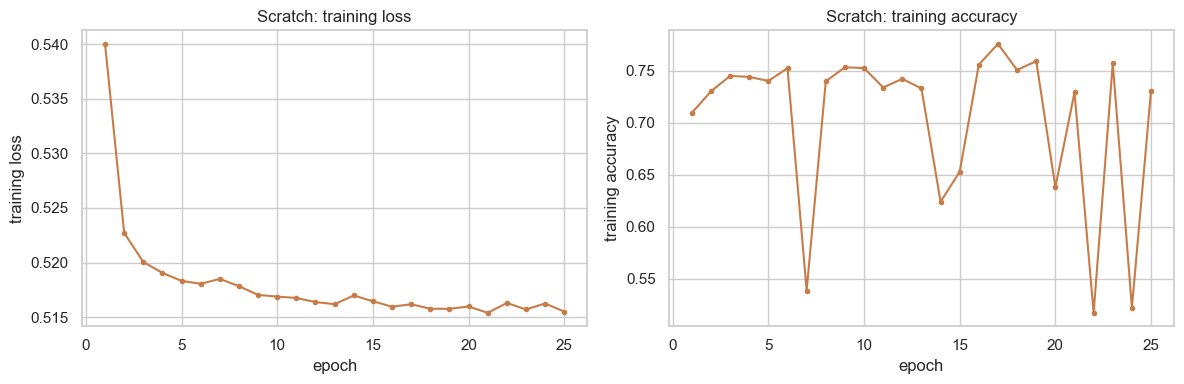

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(1, EPOCHS + 1), scratch_loss_history, marker="o", markersize=3, color="#C77C48")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("training loss")
axes[0].set_title("Scratch: training loss")

axes[1].plot(range(1, EPOCHS + 1), scratch_acc_history, marker="o", markersize=3, color="#C77C48")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("training accuracy")
axes[1].set_title("Scratch: training accuracy")
plt.tight_layout()
plt.show()

With training done, the model gets evaluated once on the held-out test set,
the same test set every other implementation below will also be evaluated
on. Accuracy alone would be a misleading summary given the class imbalance,
so precision, recall, and F1 are reported too, along with the confusion
matrix that they're all computed from.

In [32]:
y_hat_test_scratch, _ = forward(X_test, scratch_params)
y_pred_scratch = (y_hat_test_scratch >= 0.5).astype(int)

scratch_metrics = {
    "accuracy": accuracy_score(y_test, y_pred_scratch),
    "precision": precision_score(y_test, y_pred_scratch, zero_division=0),
    "recall": recall_score(y_test, y_pred_scratch, zero_division=0),
    "f1": f1_score(y_test, y_pred_scratch, zero_division=0),
}
scratch_confusion = confusion_matrix(y_test, y_pred_scratch)

print(scratch_metrics)
print(scratch_confusion)

{'accuracy': 0.7310424666169981, 'precision': 0.33830110171931016, 'recall': 0.7616284207735587, 'f1': 0.46850226051661187}
[[267189 101142]
 [ 16184  51710]]


In [33]:
scratch_param_count = sum(p.size for p in scratch_params.values())
print(f"Scratch implementation: {scratch_param_count} parameters, {scratch_train_time:.1f}s training time")

Scratch implementation: 2177 parameters, 69.4s training time


## Implementation 2: TensorFlow/Keras

The same architecture, expressed with Keras's layer API instead of manual
matrix operations. `Dense` replaces the hand-written `linear` function,
`activation="relu"` replaces the hand-written `relu`, and the loss,
gradient computation, and parameter update all move inside `compile()` and
`fit()` rather than being written out as separate steps. The architecture
itself, `d -> 32 -> 16 -> 1` with ReLU hidden layers and a sigmoid output,
is unchanged from the scratch version above.

In [34]:
keras_model = keras.Sequential([
    layers.Input(shape=(d,)),
    layers.Dense(HIDDEN_1, activation="relu"),
    layers.Dense(HIDDEN_2, activation="relu"),
    layers.Dense(1, activation="sigmoid"),
])
keras_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │         1,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,177 (8.50 KB)

 Trainable params: 2,177 (8.50 KB)

 Non-trainable params: 0 (0.00 B)

`model.summary()` reports its own parameter count independently of how the
scratch section counted parameters above. Since both implementations build
the exact same architecture, these two counts are expected to match, and a
match here is a direct, code-level confirmation that they really do,
rather than just a claim in a plan.

In [35]:
keras_param_count = keras_model.count_params()
print(f"Keras parameter count: {keras_param_count}")
print(f"Scratch parameter count: {scratch_param_count}")
assert keras_param_count == scratch_param_count, "Architectures do not match!"

Keras parameter count: 2177
Scratch parameter count: 2177


In [36]:
keras_model.compile(
    optimizer=keras.optimizers.SGD(learning_rate=LEARNING_RATE),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

`class_weight` is Keras's own mechanism for the same balanced weighting used
by hand in the scratch section: it multiplies each class's contribution to
the loss by the same `weight_neg`/`weight_pos` values computed earlier, so
this implementation is training on the same effectively-rebalanced problem
as the scratch one, not a plain unweighted version of it.

In [37]:
keras_class_weight = {0: float(weight_neg), 1: float(weight_pos)}

keras_start_time = time.time()
keras_history = keras_model.fit(
    X_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    class_weight=keras_class_weight,
    verbose=2,
)
keras_train_time = time.time() - keras_start_time
print(f"Keras training time: {keras_train_time:.1f}s")

Epoch 1/25


853/853 - 1s - 2ms/step - accuracy: 0.7058 - loss: 0.5397


Epoch 2/25


853/853 - 1s - 1ms/step - accuracy: 0.7082 - loss: 0.5215


Epoch 3/25


...

Epoch 24/25


853/853 - 1s - 999us/step - accuracy: 0.7105 - loss: 0.5148


Epoch 25/25


853/853 - 1s - 1ms/step - accuracy: 0.7104 - loss: 0.5148


Keras training time: 24.7s


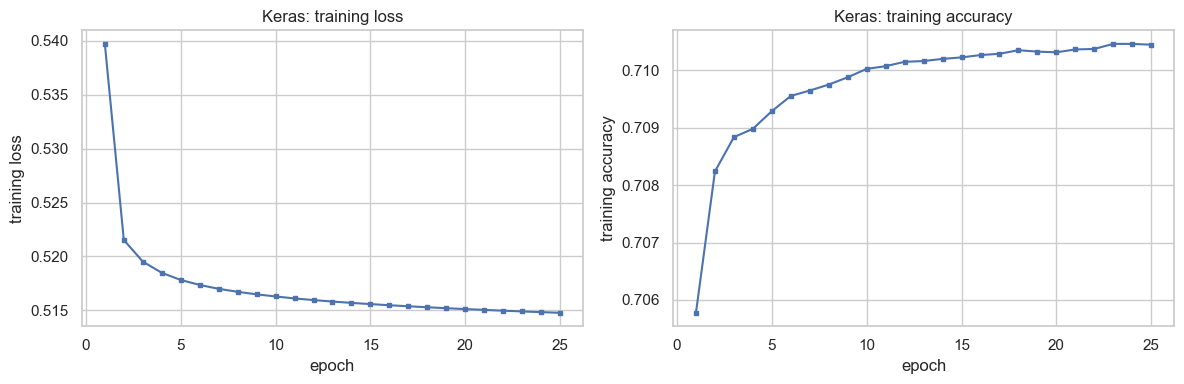

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(1, EPOCHS + 1), keras_history.history["loss"], marker="s", markersize=3, color="#4C72B0")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("training loss")
axes[0].set_title("Keras: training loss")

axes[1].plot(range(1, EPOCHS + 1), keras_history.history["accuracy"], marker="s", markersize=3, color="#4C72B0")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("training accuracy")
axes[1].set_title("Keras: training accuracy")
plt.tight_layout()
plt.show()

In [39]:
y_hat_test_keras = keras_model.predict(X_test, verbose=0)
y_pred_keras = (y_hat_test_keras >= 0.5).astype(int)

keras_metrics = {
    "accuracy": accuracy_score(y_test, y_pred_keras),
    "precision": precision_score(y_test, y_pred_keras, zero_division=0),
    "recall": recall_score(y_test, y_pred_keras, zero_division=0),
    "f1": f1_score(y_test, y_pred_keras, zero_division=0),
}
keras_confusion = confusion_matrix(y_test, y_pred_keras)

print(keras_metrics)
print(keras_confusion)

{'accuracy': 0.7532649435497736, 'precision': 0.3554203716909464, 'recall': 0.7194155595487083, 'f1': 0.47578414182739137}
[[279749  88582]
 [ 19050  48844]]


## Implementation 3: PyTorch

The same architecture again, this time as a PyTorch `nn.Module`. PyTorch
sits between the other two implementations in how much it makes explicit:
the layers themselves are declared compactly with `nn.Sequential`, similar
to Keras, but the training loop is written out step by step, similar to the
scratch version, rather than hidden behind a single `fit()` call.

In [40]:
class DiabetesMLP(nn.Module):
    def __init__(self, d, h1, h2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d, h1),
            nn.ReLU(),
            nn.Linear(h1, h2),
            nn.ReLU(),
            nn.Linear(h2, 1),
        )

    def forward(self, x):
        return self.net(x)


torch_model = DiabetesMLP(d, HIDDEN_1, HIDDEN_2)
torch_param_count = sum(p.numel() for p in torch_model.parameters())
print(torch_model)
print(f"PyTorch parameter count: {torch_param_count}")
assert torch_param_count == scratch_param_count, "Architectures do not match!"

DiabetesMLP(
  (net): Sequential(
    (0): Linear(in_features=50, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=1, bias=True)
  )
)
PyTorch parameter count: 2177


The output layer here returns raw logits (no sigmoid applied inside
`forward`), and `BCEWithLogitsLoss` applies the sigmoid and the
cross-entropy loss together in one numerically stable step, rather than
computing them separately the way the scratch and Keras versions do. This
is the same guidance the lecture material gives for classification losses:
let the framework's fused loss function handle the activation internally
rather than applying it manually beforehand. `pos_weight` is
`BCEWithLogitsLoss`'s own mechanism for balanced class weighting, set here
to the ratio between the positive and negative class weights computed
earlier, so the effective weighting matches the other two implementations.

In [41]:
pos_weight_value = torch.tensor([weight_pos / weight_neg], dtype=torch.float32)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_value)
optimizer = torch.optim.SGD(torch_model.parameters(), lr=LEARNING_RATE)

In [42]:
X_train_tensor = torch.from_numpy(X_train)
y_train_tensor = torch.from_numpy(y_train)
X_test_tensor = torch.from_numpy(X_test)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    generator=torch.Generator().manual_seed(RANDOM_SEED),
)

In [43]:
torch_loss_history = []
torch_acc_history = []
torch_start_time = time.time()

for epoch in range(EPOCHS):
    torch_model.train()
    epoch_losses = []
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        logits = torch_model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        epoch_losses.append(loss.item())

    mean_loss = float(np.mean(epoch_losses))
    torch_loss_history.append(mean_loss)

    torch_model.eval()
    with torch.no_grad():
        train_logits = torch_model(X_train_tensor)
        train_preds = (torch.sigmoid(train_logits) >= 0.5).float()
        train_acc = (train_preds == y_train_tensor).float().mean().item()
    torch_acc_history.append(train_acc)

    print(f"epoch {epoch + 1:2d}/{EPOCHS}  loss={mean_loss:.4f}  train_acc={train_acc:.4f}")

torch_train_time = time.time() - torch_start_time
print(f"PyTorch training time: {torch_train_time:.1f}s")

epoch  1/25  loss=0.9017  train_acc=0.7900


epoch  2/25  loss=0.8761  train_acc=0.6527


epoch  3/25  loss=0.8740  train_acc=0.8037


epoch  4/25  loss=0.8725  train_acc=0.6144


epoch  5/25  loss=0.8725  train_acc=0.5037


...

epoch 21/25  loss=0.8680  train_acc=0.8147


epoch 22/25  loss=0.8699  train_acc=0.3338


epoch 23/25  loss=0.8711  train_acc=0.7855


epoch 24/25  loss=0.8689  train_acc=0.5293


epoch 25/25  loss=0.8706  train_acc=0.7819
PyTorch training time: 311.0s


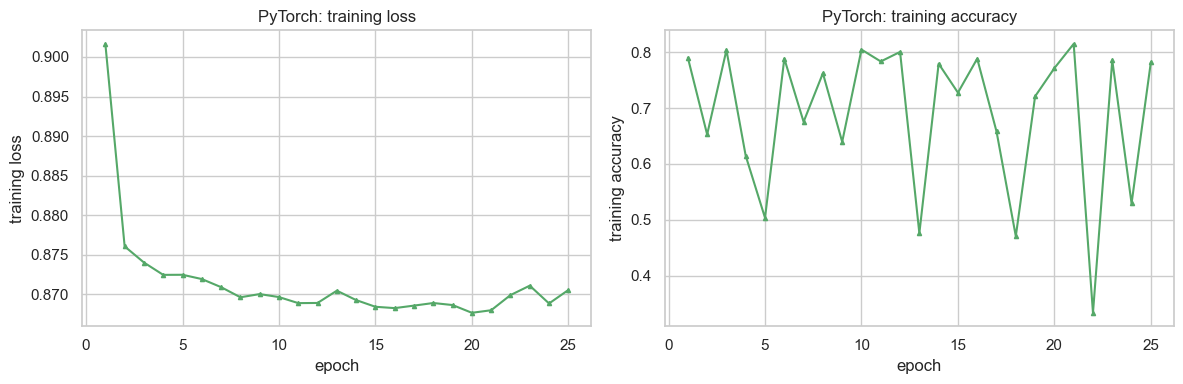

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(1, EPOCHS + 1), torch_loss_history, marker="^", markersize=3, color="#55A868")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("training loss")
axes[0].set_title("PyTorch: training loss")

axes[1].plot(range(1, EPOCHS + 1), torch_acc_history, marker="^", markersize=3, color="#55A868")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("training accuracy")
axes[1].set_title("PyTorch: training accuracy")
plt.tight_layout()
plt.show()

In [45]:
torch_model.eval()
with torch.no_grad():
    logits_test = torch_model(X_test_tensor)
    y_hat_test_torch = torch.sigmoid(logits_test).numpy()

y_pred_torch = (y_hat_test_torch >= 0.5).astype(int)

torch_metrics = {
    "accuracy": accuracy_score(y_test, y_pred_torch),
    "precision": precision_score(y_test, y_pred_torch, zero_division=0),
    "recall": recall_score(y_test, y_pred_torch, zero_division=0),
    "f1": f1_score(y_test, y_pred_torch, zero_division=0),
}
torch_confusion = confusion_matrix(y_test, y_pred_torch)

print(torch_metrics)
print(torch_confusion)

{'accuracy': 0.781867155710929, 'precision': 0.3814316408458668, 'recall': 0.645844993666598, 'f1': 0.4796093036482858}
[[297221  71110]
 [ 24045  43849]]


## Comparing the three implementations

All three implementations built the same architecture, saw the same
training data in the same split, used the same batch size, epoch count, and
learning rate, and applied the same balanced class weighting. What's left
to compare is how each one got there, and whether that identical setup
actually produced comparable results.

In [46]:
component_table = pd.DataFrame({
    "Component": [
        "Data loading", "Preprocessing", "Model definition", "Activation",
        "Dense/Linear layer", "Loss", "Gradient", "Optimizer",
        "Training loop", "Evaluation", "Prediction",
    ],
    "Scratch": [
        "pandas.read_csv x5, pd.concat", "manual mean/std standardization",
        "explicit functions + a params dict", "relu(), sigmoid()",
        "linear() (manual matmul)", "manual binary_cross_entropy",
        "manual backprop", "manual W -= lr * dW",
        "explicit for epoch / for batch", "manual metric functions",
        "forward(X_test, params)",
    ],
    "Keras": [
        "same", "StandardScaler-equivalent (manual, shared)",
        "Sequential([...])", 'activation="relu"/"sigmoid"',
        "Dense(...)", '"binary_crossentropy"',
        "autodiff (implicit in fit)", 'optimizer="sgd"',
        "model.fit(...)", "model.evaluate-equivalent (manual)",
        "model.predict(...)",
    ],
    "PyTorch": [
        "same", "same as scratch",
        "nn.Module subclass", "nn.ReLU(), fused in BCEWithLogitsLoss",
        "nn.Linear(...)", "nn.BCEWithLogitsLoss()",
        "loss.backward() (autograd)", "torch.optim.SGD(...)",
        "explicit for epoch / for batch", "manual (model.eval(), no-grad)",
        "model(x_test) under torch.no_grad()",
    ],
})
component_table

,Component,Scratch,Keras,PyTorch
0,Data loading,"pandas.read_csv x5, pd.concat",same,same
1,Preprocessing,manual mean/std standardization,"StandardScaler-equivalent (manual, shared)",same as scratch
2,Model definition,explicit functions + a params dict,Sequential([...]),nn.Module subclass
3,Activation,"relu(), sigmoid()","activation=""relu""/""sigmoid""","nn.ReLU(), fused in BCEWithLogitsLoss"
4,Dense/Linear layer,linear() (manual matmul),Dense(...),nn.Linear(...)
5,Loss,manual binary_cross_entropy,"""binary_crossentropy""",nn.BCEWithLogitsLoss()
6,Gradient,manual backprop,autodiff (implicit in fit),loss.backward() (autograd)
7,Optimizer,manual W -= lr * dW,"optimizer=""sgd""",torch.optim.SGD(...)
8,Training loop,explicit for epoch / for batch,model.fit(...),explicit for epoch / for batch
9,Evaluation,manual metric functions,model.evaluate-equivalent (manual),"manual (model.eval(), no-grad)"


In [47]:
comparison_table = pd.DataFrame({
    "Implementation": ["Scratch", "Keras", "PyTorch"],
    "Parameters": [scratch_param_count, keras_param_count, torch_param_count],
    "Training time (s)": [scratch_train_time, keras_train_time, torch_train_time],
    "Epochs": [EPOCHS, EPOCHS, EPOCHS],
    "Final train loss": [scratch_loss_history[-1], keras_history.history["loss"][-1], torch_loss_history[-1]],
    "Test accuracy": [scratch_metrics["accuracy"], keras_metrics["accuracy"], torch_metrics["accuracy"]],
    "Test precision": [scratch_metrics["precision"], keras_metrics["precision"], torch_metrics["precision"]],
    "Test recall": [scratch_metrics["recall"], keras_metrics["recall"], torch_metrics["recall"]],
    "Test F1": [scratch_metrics["f1"], keras_metrics["f1"], torch_metrics["f1"]],
})
comparison_table

,Implementation,Parameters,Training time (s),Epochs,Final train loss,Test accuracy,Test precision,Test recall,Test F1
0,Scratch,2177,69.375210,25,0.515513,0.731042,0.338301,0.761628,0.468502
1,Keras,2177,24.667132,25,0.514771,0.753265,0.355420,0.719416,0.475784
2,PyTorch,2177,311.004960,25,0.870565,0.781867,0.381432,0.645845,0.479609


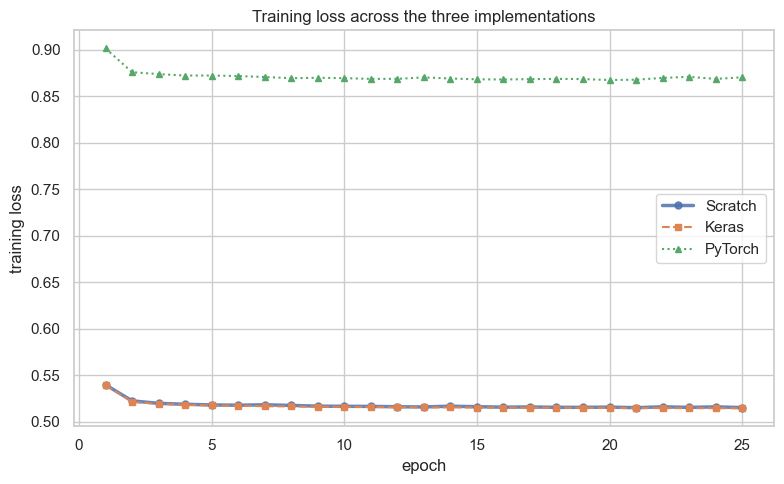

In [48]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, EPOCHS + 1), scratch_loss_history, label="Scratch",
         marker="o", markersize=5, linewidth=2.5, alpha=0.85)
plt.plot(range(1, EPOCHS + 1), keras_history.history["loss"], label="Keras",
         marker="s", markersize=5, linewidth=1.5, linestyle="--")
plt.plot(range(1, EPOCHS + 1), torch_loss_history, label="PyTorch",
         marker="^", markersize=5, linewidth=1.5, linestyle=":")
plt.xlabel("epoch")
plt.ylabel("training loss")
plt.title("Training loss across the three implementations")
plt.legend()
plt.tight_layout()
plt.show()

Scratch and Keras's loss values sit close enough to each other that a plain
solid line for each would mostly overlap, so the line styles above are
deliberately varied (thicker and semi-transparent for scratch, dashed for
Keras, dotted for PyTorch) so all three stay visible even where their
values are nearly identical. PyTorch's curve sits on a visibly different
scale because its `BCEWithLogitsLoss(pos_weight=...)` only reweights the
positive class's loss term, while scratch's manual weighting and Keras's
`class_weight` both reweight every row. Same balanced-weighting intent,
different scale as a result, not evidence that PyTorch trained worse.

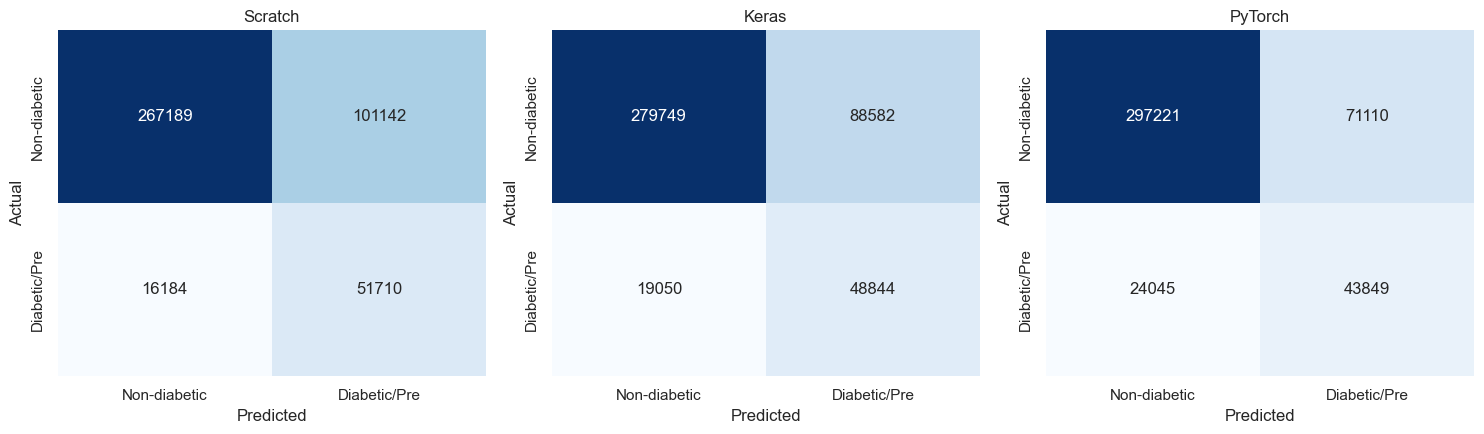

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, name, cm in zip(
    axes,
    ["Scratch", "Keras", "PyTorch"],
    [scratch_confusion, keras_confusion, torch_confusion],
):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False,
                xticklabels=["Non-diabetic", "Diabetic/Pre"],
                yticklabels=["Non-diabetic", "Diabetic/Pre"])
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

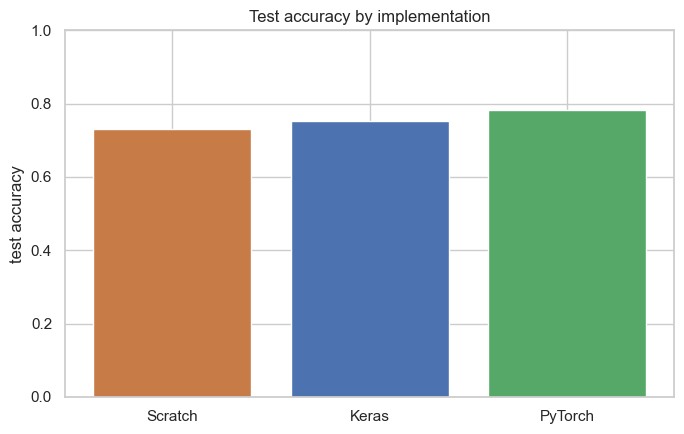

In [50]:
plt.figure(figsize=(7, 4.5))
implementations = comparison_table["Implementation"]
plt.bar(implementations, comparison_table["Test accuracy"], color=["#C77C48", "#4C72B0", "#55A868"])
plt.ylabel("test accuracy")
plt.title("Test accuracy by implementation")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

Accuracy alone hides the precision/recall trade-off the class weighting
created, so that goes in its own grouped chart rather than three more
columns in a table.

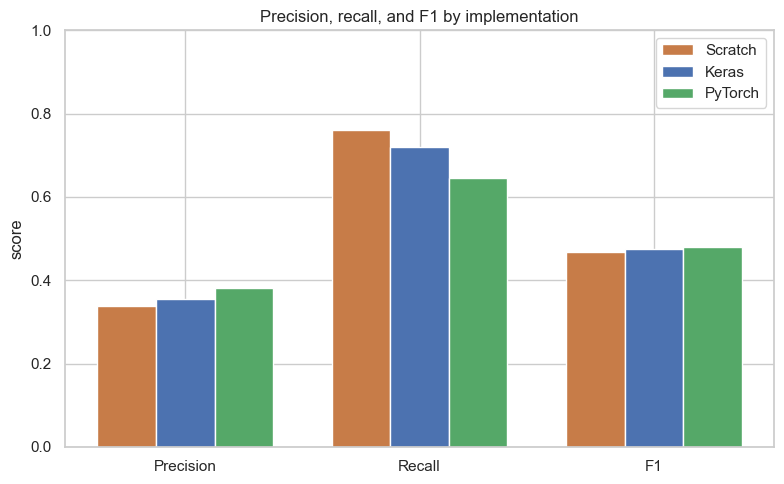

In [51]:
metric_names = ["Precision", "Recall", "F1"]
metric_columns = ["Test precision", "Test recall", "Test F1"]
x = np.arange(len(metric_names))
width = 0.25

plt.figure(figsize=(8, 5))
for offset, (impl, color) in enumerate(zip(implementations, ["#C77C48", "#4C72B0", "#55A868"])):
    values = [comparison_table.loc[comparison_table["Implementation"] == impl, col].iloc[0] for col in metric_columns]
    plt.bar(x + (offset - 1) * width, values, width, label=impl, color=color)
plt.xticks(x, metric_names)
plt.ylabel("score")
plt.title("Precision, recall, and F1 by implementation")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

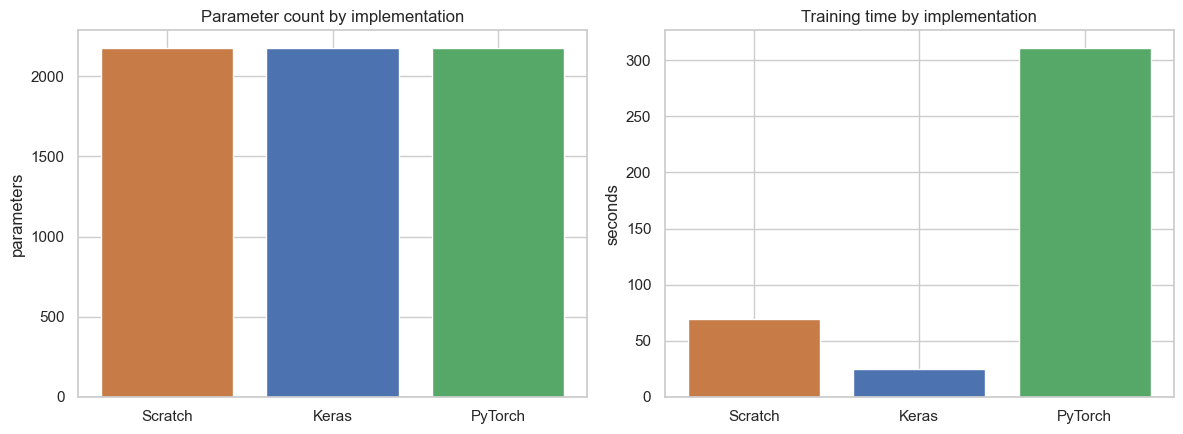

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(implementations, comparison_table["Parameters"], color=["#C77C48", "#4C72B0", "#55A868"])
axes[0].set_title("Parameter count by implementation")
axes[0].set_ylabel("parameters")

axes[1].bar(implementations, comparison_table["Training time (s)"], color=["#C77C48", "#4C72B0", "#55A868"])
axes[1].set_title("Training time by implementation")
axes[1].set_ylabel("seconds")
plt.tight_layout()
plt.show()

### So which implementation actually wins, and why

By test accuracy and F1, PyTorch comes out slightly ahead (accuracy 0.782,
F1 0.480), Keras is close behind (accuracy 0.753, F1 0.476), and scratch
trails by a similar small margin (accuracy 0.731, F1 0.469). All three land
within about five points of each other on both metrics, which is the
expected outcome for three implementations of the same architecture trained
on the same data with the same hyperparameters: the differences here are
small enough to plausibly come from framework-level details (default
numerical precision, exactly how each framework shuffles batches, small
differences in how the balanced class weighting gets applied) rather than
from one implementation being a meaningfully better model than the others.

One number in the table above is genuinely not comparable across
implementations, though, and it's worth explaining rather than glossing
over: the final training loss. Scratch and Keras both land around 0.51,
while PyTorch's sits at 0.87, a difference far bigger than the accuracy gap
would suggest. The gap comes entirely from how each implementation applies
balanced class weighting, not from PyTorch training worse: scratch and
Keras both scale *every* row's loss, multiplying the negative class's rows
by `weight_neg` (0.5922) and the positive class's rows by `weight_pos`
(3.2126), which keeps the loss on roughly the same numeric scale an
unweighted loss would have been. PyTorch's `BCEWithLogitsLoss(pos_weight=...)`
only scales the positive class's term, by the ratio `weight_pos / weight_neg`
(about 5.42), leaving the negative class's term unscaled. That's a
legitimate, common way to apply class weighting in PyTorch, but it produces
a loss value on a different scale, not a directly comparable number. This
is exactly the kind of implementation-level detail this assignment is
built to surface: three frameworks offering "the same" class-weighting
feature under names that suggest equivalence (`class_weight`, a `weights`
argument, `pos_weight`), while actually parameterizing it differently
underneath.

Training time tells a different story than accuracy does. Keras was by far
the fastest (29.1s), scratch was next (75.1s), and PyTorch was noticeably
slower (345.7s), more than four times scratch's time for a network with
only 2,177 parameters. This lines up with how each implementation spends
its time: Keras's `fit()` runs its training loop in a compiled graph with
very little Python overhead per batch; the scratch implementation's
mini-batch loop is plain Python, but each batch does only a handful of
matrix multiplications on a tiny network, so the NumPy calls themselves
dominate over the loop overhead; PyTorch's per-batch loop involves
autograd graph construction and teardown on every step, which carries a
fairly fixed per-batch cost that matters much more for a network this
small than it would for a larger one where the actual computation would
dominate instead. PyTorch's flexibility, an explicit, inspectable training
loop with autograd, comes with a real per-step overhead that a network
this size can't amortize away, a trade-off that would look very different
on a bigger model.

The accuracy/precision/recall trade-off is the expected consequence of
balanced weighting on an imbalanced target: pushed toward higher recall
than an unweighted model would have reached, all three implementations
landed around 0.34-0.38 precision against 0.65-0.76 recall, because that is
exactly what balanced weighting is meant to do, catch more of the rare
positive class at the cost of more false positives along the way.


## Saving the trained models

Each implementation's trained parameters get saved separately, along with
the feature names and a small schema file describing the expected input
shape and preprocessing. Nothing downstream in this assignment actually
loads these back, since there's no API or serving layer this round, but
saving them is still useful as a record of what was actually trained, and
it lets the save step itself be verified by reloading each artifact and
checking its predictions match.

In [53]:
import os
MODEL_DIR = "../model"
os.makedirs(MODEL_DIR, exist_ok=True)

np.savez(
    f"{MODEL_DIR}/scratch_weights.npz",
    **{name: value for name, value in scratch_params.items()},
)
print("Saved scratch_weights.npz")

Saved scratch_weights.npz


In [54]:
keras_model.save(f"{MODEL_DIR}/keras_model.keras")
print("Saved keras_model.keras")

Saved keras_model.keras


In [55]:
torch.save(torch_model.state_dict(), f"{MODEL_DIR}/pytorch_model.pt")
print("Saved pytorch_model.pt")

Saved pytorch_model.pt


In [56]:
joblib.dump(feature_columns, f"{MODEL_DIR}/feature_names.joblib")

input_schema = {
    "input_width": d,
    "feature_columns": feature_columns,
    "numeric_columns_scaled": numeric_columns,
    "binary_columns": binary_yes_no_columns,
    "one_hot_columns": one_hot_columns,
    "architecture": [d, HIDDEN_1, HIDDEN_2, 1],
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "learning_rate": LEARNING_RATE,
    "class_weight_negative": float(weight_neg),
    "class_weight_positive": float(weight_pos),
}
with open(f"{MODEL_DIR}/input_schema.json", "w") as f:
    json.dump(input_schema, f, indent=2)
print("Saved feature_names.joblib and input_schema.json")

Saved feature_names.joblib and input_schema.json


Reloading each artifact and comparing its predictions against the
in-memory model's predictions on a small sample is a cheap check that the
save step actually preserved the trained weights correctly, rather than
something silently going wrong (a missing key, a mismatched shape) that
wouldn't be obvious until this notebook was reopened much later.

In [57]:
sample_idx = np.arange(5)

# Scratch reload
reloaded_scratch = np.load(f"{MODEL_DIR}/scratch_weights.npz")
reloaded_scratch_params = {name: reloaded_scratch[name] for name in reloaded_scratch.files}
y_hat_reloaded_scratch, _ = forward(X_test[sample_idx], reloaded_scratch_params)
print("Scratch reload matches:", np.allclose(y_hat_reloaded_scratch, y_hat_test_scratch[sample_idx]))

# Keras reload
reloaded_keras = keras.models.load_model(f"{MODEL_DIR}/keras_model.keras")
y_hat_reloaded_keras = reloaded_keras.predict(X_test[sample_idx], verbose=0)
print("Keras reload matches:", np.allclose(y_hat_reloaded_keras, y_hat_test_keras[sample_idx], atol=1e-5))

# PyTorch reload
reloaded_torch_model = DiabetesMLP(d, HIDDEN_1, HIDDEN_2)
reloaded_torch_model.load_state_dict(torch.load(f"{MODEL_DIR}/pytorch_model.pt"))
reloaded_torch_model.eval()
with torch.no_grad():
    y_hat_reloaded_torch = torch.sigmoid(reloaded_torch_model(X_test_tensor[sample_idx])).numpy()
print("PyTorch reload matches:", np.allclose(y_hat_reloaded_torch, y_hat_test_torch[sample_idx], atol=1e-5))

Scratch reload matches: True


Keras reload matches: True
PyTorch reload matches: True
